In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better visualizations
plt.style.use('seaborn')
sns.set_palette("husl")

# Read the data
treadmill_df = pd.read_csv('merged.csv')


/var/folders/bn/28hly9dd0z36556zl0gx44v80000gn/T/ipykernel_39694/3130444460.py:41: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(scatter)


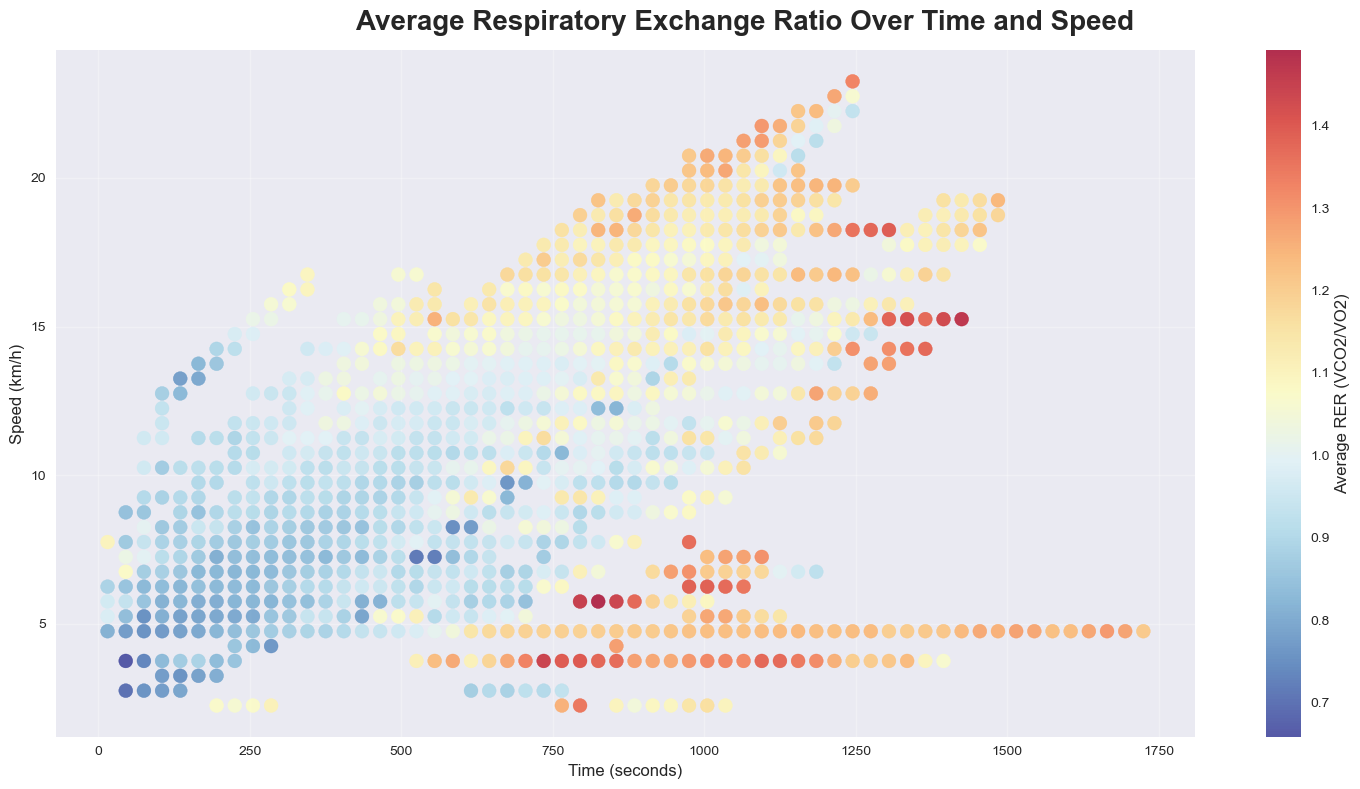

In [11]:
def plot_re_scatter_binned():
    # Read data
    df = treadmill_df.copy()
    
    # Calculate RER
    
    # Ensure time bins start at 0 and increment by 30 seconds
    df['time_bin'] = pd.cut(df['time'], 
                        bins=np.arange(0, df['time'].max() + 31, 30),  # Ensuring inclusive bins
                        labels=False)  # Numeric labels
    df['time_bin'] = df['time_bin'] * 30 + 15  # Center of each bin

    # Ensure speed bins start at the nearest whole number and increment by 0.5 km/h
    speed_min = np.floor(df['Speed'].min())  # Start from the nearest whole number
    speed_max = np.ceil(df['Speed'].max())   # Ceiling to cover max range

    df['speed_bin'] = pd.cut(df['Speed'], 
                         bins=np.arange(speed_min, speed_max + 0.51, 0.5),  # Inclusive upper bound
                         labels=False)
    df['speed_bin'] = df['speed_bin'] * 0.5 + speed_min + 0.25  # Center of each bin
    
    # Calculate average RER for each time-speed combination
    binned_data = df.groupby(['time_bin', 'speed_bin'])['RER'].mean().reset_index()
    
    # Create the visualization
    plt.figure(figsize=(15, 8))
    
    # Set background color
    ax = plt.gca()
    ax.set_facecolor('#EAEAF2')
    
    # Create scatter plot with binned data
    scatter = plt.scatter(binned_data['time_bin'], 
                         binned_data['speed_bin'],
                         c=binned_data['RER'],
                         cmap='RdYlBu_r',
                         s=100,  # Increased marker size for better visibility
                         alpha=0.8)
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Average RER (VCO2/VO2)', fontsize=12)
    
    # Set title and labels
    plt.suptitle('Average Respiratory Exchange Ratio Over Time and Speed', 
                 fontsize=20, fontweight='bold')
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Speed (km/h)', fontsize=12)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return plt.gcf()

# Create and display the plot
fig = plot_re_scatter_binned()
plt.show()

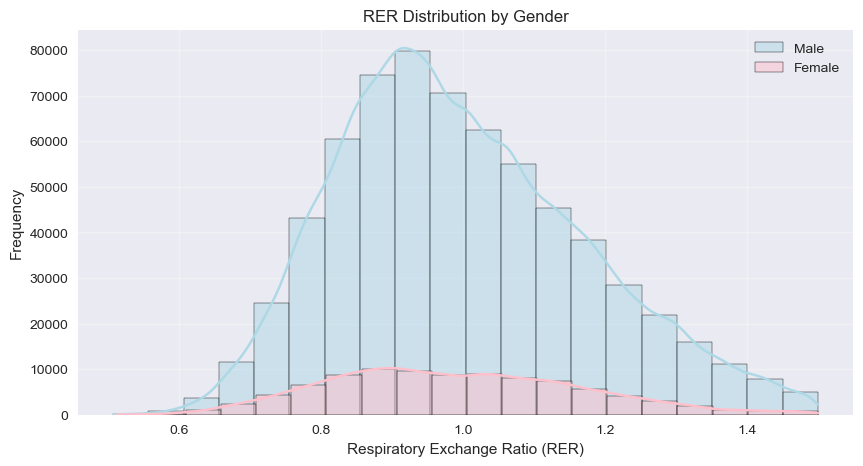

In [21]:
# Plot histogram
plt.figure(figsize=(10, 5))
sns.histplot(treadmill_df[treadmill_df['Sex'] == 0]['RER'], bins=20, kde=True, color='lightblue', label='Male')
sns.histplot(treadmill_df[treadmill_df['Sex'] == 1]['RER'], bins=20, kde=True, color='pink', label='Female')

# Customize the plot
plt.xlabel('Respiratory Exchange Ratio (RER)')
plt.ylabel('Frequency')
plt.title('RER Distribution by Gender')
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.show()

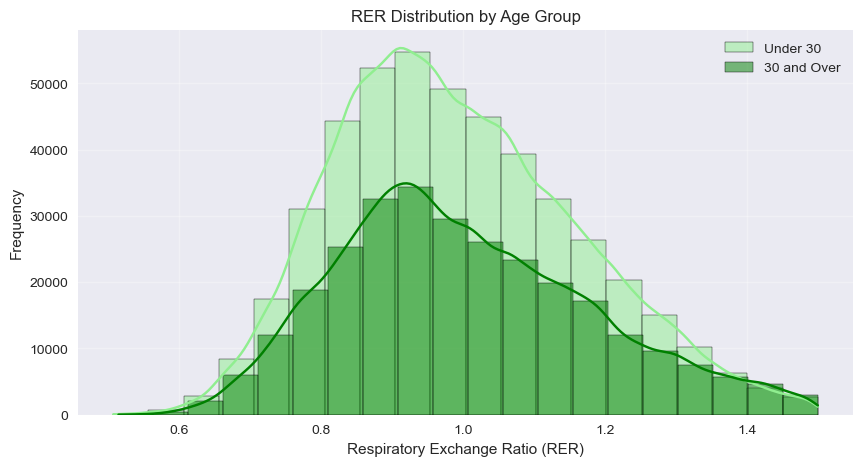

In [16]:
# Filter Data by Age
under_30 = treadmill_df[treadmill_df['Age'] < 30]['RER']
over_30 = treadmill_df[treadmill_df['Age'] >= 30]['RER']

# Plot histogram
plt.figure(figsize=(10, 5))
sns.histplot(under_30, bins=20, kde=True, color='lightgreen', label='Under 30')
sns.histplot(over_30, bins=20, kde=True, color='green', label='30 and Over')

# Customize the plot
plt.xlabel('Respiratory Exchange Ratio (RER)')
plt.ylabel('Frequency')
plt.title('RER Distribution by Age Group')
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.show()

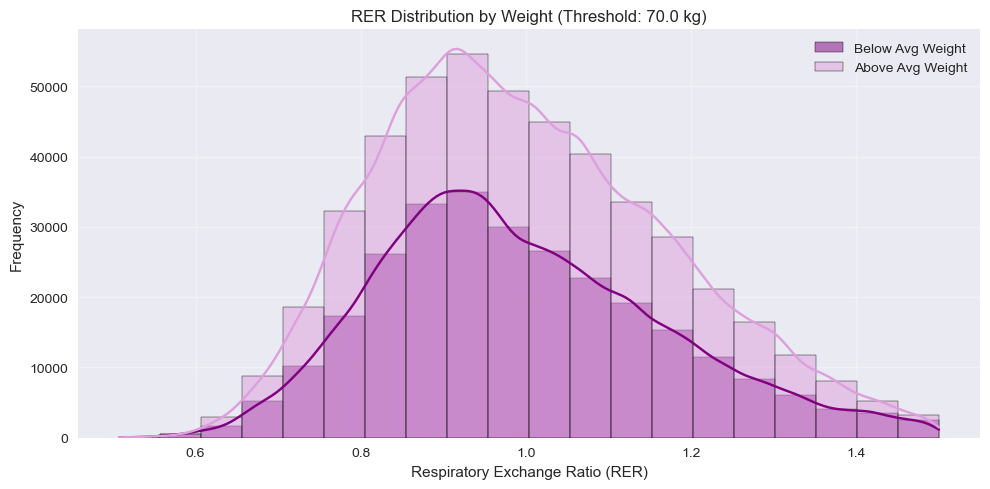

In [33]:
# Calculate mean thresholds
avg_weight = 70

# Filter Data by Weight
lighter = treadmill_df[treadmill_df['Weight'] < avg_weight]['RER']
heavier = treadmill_df[treadmill_df['Weight'] >= avg_weight]['RER']

# Create subplots
plt.figure(figsize=(10, 5))

# Plot histogram by Weight
sns.histplot(lighter, bins=20, kde=True, color='purple', label='Below Avg Weight')
sns.histplot(heavier, bins=20, kde=True, color='plum', label='Above Avg Weight')
plt.title(f'RER Distribution by Weight (Threshold: {avg_weight:.1f} kg)')
plt.xlabel('Respiratory Exchange Ratio (RER)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()


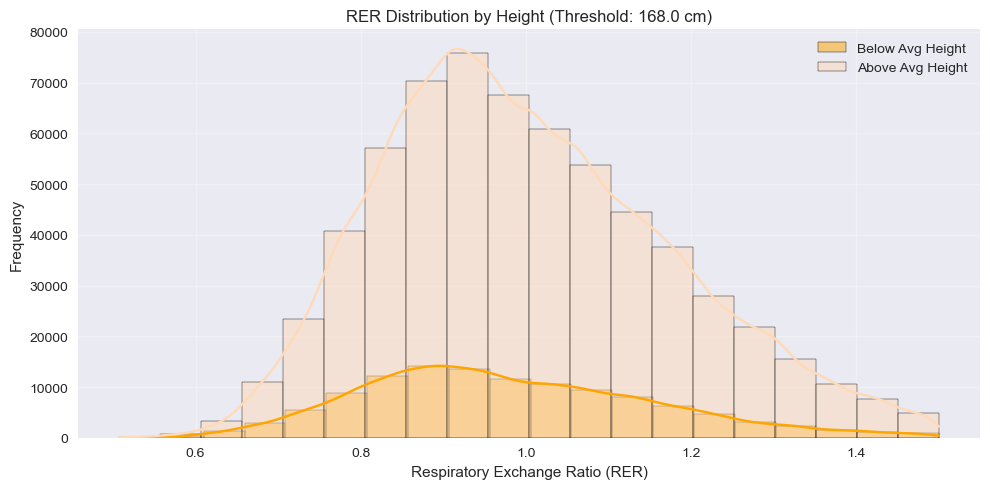

In [34]:
avg_height = 168

# Filter Data by Height
shorter = treadmill_df[treadmill_df['Height'] < avg_height]['RER']
taller = treadmill_df[treadmill_df['Height'] >= avg_height]['RER']


# Create subplots
plt.figure(figsize=(10, 5))

# Plot histogram by Height
sns.histplot(shorter, bins=20, kde=True, color='orange', label='Below Avg Height')
sns.histplot(taller, bins=20, kde=True, color='peachpuff', label='Above Avg Height')
plt.title(f'RER Distribution by Height (Threshold: {avg_height:.1f} cm)')
plt.xlabel('Respiratory Exchange Ratio (RER)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()